-Krishnanjan Sil

#Given Code:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as constant
import scipy.integrate as integrate
import scipy.special as special
from matplotlib.widgets import Slider

# Defining constants
hbar = constant.hbar
m_e = constant.electron_mass
eV = constant.electron_volt
e = constant.elementary_charge
pi = constant.pi

# Global parameters
timeIntervals = 1000
spaceIntervals = 1000
timePeriod = 100 # in nanoseconds
a = 0.01 # in micrometres
tolerance = 1e-3

# Infinite Square Well (ISW)
def ISW_Wavefunction(energyLevel, wellWidth, timePeriod): # wellWidth in um, timePeriod in ns
    n = energyLevel
    a = wellWidth * 1e-6
    time = timePeriod * 1e-9
    x = np.linspace(0, a, spaceIntervals)
    t = np.linspace(0, time, timeIntervals)
    x, t = np.meshgrid(x, t, indexing= "ij")
    Energy = n**2 * pi**2 * hbar ** 2 / (2 * m_e * a**2)
    spaceTerm = np.sqrt(2 / a) * np.sin(n * pi * x / a)
    timeTerm = np.exp(-1j * Energy * t / hbar)
    probAmp =  spaceTerm * timeTerm
    return probAmp, Energy

# Harmonic Oscillator (HO)
def HO_Wavefunction(energyLevel, spaceLowerLim, spaceUpperLim, timePeriod): # spaceLimits in um, timePeriod in ns
    n = energyLevel
    extent = (spaceUpperLim - spaceLowerLim) * 1e-6
    sigma = extent / 10 # width of the ground state
    omega = hbar / ( 2 * m_e * sigma**2)
    Energy = hbar * omega * (n + 1/2)
    time = timePeriod * 1e-9
    x = np.linspace(- extent / 2, extent / 2, spaceIntervals)
    t = np.linspace(0, time, timeIntervals)
    x, t = np.meshgrid(x, t, indexing= "ij")
    xi = np.sqrt(m_e * omega / hbar) * x
    nth_Hermite = special.hermite(n)
    spaceTerm = np.float_power((m_e * omega / (pi * hbar)), 0.25) * 1 / np.sqrt(2**n * special.factorial(n)) * nth_Hermite(xi) * np.exp(- xi**2 / 2)
    timeTerm = np.exp(-1j * Energy * t / hbar)
    probAmp =  spaceTerm * timeTerm
    return probAmp, Energy

# Obtain the probability current from the wavefunction
def probabilityCurrent(probAmp, spaceLowerLim, spaceUpperLim):
    x = np.linspace(spaceLowerLim, spaceUpperLim, spaceIntervals) * 1e-6
    probCurrent = 1j * hbar / (2 * m_e) * (probAmp * np.gradient(np.conjugate(probAmp), x, axis = 0) - np.conjugate(probAmp) * np.gradient(probAmp, x, axis = 0))
    return np.real_if_close(probCurrent) # np.real_if_close accounts for non-zero imaginary part due to numerical errors

# Convert wavefunction (probability amplitude) to probability density
def probabilityDensity(probAmp):
    probAmp_conj = np.conjugate(probAmp)
    probDensity = probAmp_conj * probAmp
    return np.real_if_close(probDensity)

# Verify Normalisation
def checkNormalisation(probAmp, spaceLowerLim, spaceUpperLim):
    probDensity = probabilityDensity(probAmp)
    spaceArray = np.linspace(spaceLowerLim, spaceUpperLim, spaceIntervals) * 1e-6
    result = integrate.trapezoid(probDensity, spaceArray, axis = 0) # integration over x
    return np.all(np.abs(1 - result) < tolerance), result

# Normalise if the wavefunction is isn't normalised
def Normalise(probAmp, spaceLowerLim, spaceUpperLim):
    normalisationFlag = False
    normalisationFlag, integral = checkNormalisation(probAmp, spaceLowerLim, spaceUpperLim)
    if normalisationFlag is True:
        print("The wavefunction is already normalised!")
    else:
        normalisationConst = np.sqrt(1/integral)
        normalisedWavefunction = normalisationConst * probAmp
        return normalisedWavefunction, np.real_if_close(normalisationConst[0])

# Plot Wavefunction
def wavefunctionPlot(probAmp, spaceLowerLim, spaceUpperLim, timePeriod):
    x = np.linspace(spaceLowerLim, spaceUpperLim, spaceIntervals) * 1e-6

    # 2D plots for real and imaginary parts of the wavefunction
    fig2D, (ax1, ax2) = plt.subplots(1, 2)
    plt.subplots_adjust(bottom=0.20)
    timeAx = plt.axes([0.1, 0.05, 0.8, 0.05])
    timeSlider = Slider(timeAx, "Time", valmin = 0.0, valmax = timePeriod, valinit = 0.0, valstep = timePeriod / timeIntervals)
    realPart, = ax1.plot(x * 1e+6, np.real(probAmp)[:, 0], linewidth = 2, color = 'blue')
    ax1.set_ylim([-np.max(np.real(probAmp)) * 1.25, np.max(np.real(probAmp)) * 1.25])
    ax1.set_title("Real part of the Wavefunction")
    ax1.set_xlabel("Position $x$ (in $\mu m$)")
    ax1.set_ylabel("Re $\Psi(x,t)$")
    ax1.grid(True)

    imagPart, = ax2.plot(x * 1e+6, np.imag(probAmp)[:, 0], linewidth = 2, color = 'red')
    ax2.set_ylim([-np.max(np.imag(probAmp)) * 1.25, np.max(np.imag(probAmp)) * 1.25])
    ax2.set_title("Imaginary part of the Wavefunction")
    ax2.set_xlabel("Position $x$ (in $\mu m$)")
    ax2.set_ylabel("Im $\Psi(x,t)$")
    ax2.grid(True)

    # Time Slider
    def updateSlider(val):
        frame = int(val / timePeriod * (timeIntervals - 1))
        realPart.set_ydata(np.real(probAmp)[:, frame])
        imagPart.set_ydata(np.imag(probAmp)[:, frame])
        timeAx.set_title(f"Time = {val:.1f} ns")
        fig2D.canvas.draw_idle()

    timeSlider.on_changed(updateSlider)
    plt.show()

# Plot Probability Density
def probDensityPlot(probDensity, spaceLowerLim, spaceUpperLim, timePeriod):
    x = np.linspace(spaceLowerLim, spaceUpperLim, spaceIntervals) * 1e-6

    fig, ax = plt.subplots()
    plt.subplots_adjust(bottom=0.20)
    timeAx = plt.axes([0.1, 0.05, 0.8, 0.05])
    timeSlider = Slider(timeAx, "Time", valmin = 0.0, valmax = timePeriod, valinit = 0.0, valstep = timePeriod / timeIntervals)
    densityPlot, = ax.plot(x * 1e+6, probDensity[:, 0], linewidth = 2, color = 'blue')
    ax.set_title("Probability Density")
    ax.set_xlabel("Position $x$ (in $\mu m$)")
    ax.set_ylabel("$|\Psi(x,t)|^2$")
    ax.grid(True)

    # Time Slider
    def updateSlider(val):
        frame = int(val / timePeriod * (timeIntervals - 1))
        densityPlot.set_ydata(np.real(probDensity)[:, frame])
        timeAx.set_title(f"Time = {val:.1f} ns")
        fig.canvas.draw_idle()

    timeSlider.on_changed(updateSlider)
    plt.show()

# Plot Probability Current
def probCurrentPlot(probCurrent, spaceLowerLim, spaceUpperLim, timePeriod):
    x = np.linspace(spaceLowerLim, spaceUpperLim, spaceIntervals) * 1e-6
    fig, ax = plt.subplots()
    plt.subplots_adjust(bottom=0.20)
    timeAx = plt.axes([0.1, 0.05, 0.8, 0.05])
    timeSlider = Slider(timeAx, "Time", valmin = 0.0, valmax = timePeriod, valinit = 0.0, valstep = timePeriod / timeIntervals)
    currentPlot, = ax.plot(x * 1e+6, probCurrent[:, 0], linewidth = 2, color = 'blue')
    ax.set_ylim([-np.max(probCurrent) * 1.25, np.max(probCurrent) * 1.25])
    ax.set_title("Probability Current")
    ax.set_xlabel("Position $x$ (in $\mu m$)")
    ax.set_ylabel("$J(x,t)$")
    ax.grid(True)

    # Time Slider
    def updateSlider(val):
        frame = int(val / timePeriod * (timeIntervals - 1))
        currentPlot.set_ydata(np.real(probCurrent)[:, frame])
        timeAx.set_title(f"Time = {val:.1f} ns")
        fig.canvas.draw_idle()

    timeSlider.on_changed(updateSlider)
    plt.show()

<>:96: SyntaxWarning: invalid escape sequence '\m'
<>:97: SyntaxWarning: invalid escape sequence '\P'
<>:103: SyntaxWarning: invalid escape sequence '\m'
<>:104: SyntaxWarning: invalid escape sequence '\P'
<>:128: SyntaxWarning: invalid escape sequence '\m'
<>:129: SyntaxWarning: invalid escape sequence '\P'
<>:152: SyntaxWarning: invalid escape sequence '\m'
<>:96: SyntaxWarning: invalid escape sequence '\m'
<>:97: SyntaxWarning: invalid escape sequence '\P'
<>:103: SyntaxWarning: invalid escape sequence '\m'
<>:104: SyntaxWarning: invalid escape sequence '\P'
<>:128: SyntaxWarning: invalid escape sequence '\m'
<>:129: SyntaxWarning: invalid escape sequence '\P'
<>:152: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-1135490268.py:96: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel("Position $x$ (in $\mu m$)")
/tmp/ipython-input-1135490268.py:97: SyntaxWarning: invalid escape sequence '\P'
  ax1.set_ylabel("Re $\Psi(x,t)$")
/tmp/ipython-input-1135490268.py:

# Task 2:

##  Mathematically, for two states $\Psi_n$ and $\Psi_m$ where $n \neq m$, the inner product should be zero:$$\langle \Psi_n | \Psi_m \rangle = \int_{-\infty}^{\infty} \Psi_n^*(x, t) \Psi_m(x, t) \, dx = 0$$

In [2]:
# --- Task 2: Orthogonality Verification ---

def verify_orthogonality(func, n1, n2, **kwargs):
    # Fetch wavefunctions for two different levels
    psi1, _ = func(energyLevel=n1, **kwargs)
    psi2, _ = func(energyLevel=n2, **kwargs)

    # Calculate overlap integral <Psi1 | Psi2>
    # Note: We check at t=0 (index 0) for simplicity, but it holds for all t
    overlap = np.trapz(np.conj(psi1[:, 0]) * psi2[:, 0], dx=(kwargs.get('spaceUpperLim', 0.01) - kwargs.get('spaceLowerLim', 0)) * 1e-6 / (spaceIntervals - 1))

    # For ISW, spaceUpperLim is just 'wellWidth' effectively
    if func == ISW_Wavefunction:
        dx = kwargs['wellWidth'] * 1e-6 / spaceIntervals
        overlap = np.sum(np.conj(psi1[:, 0]) * psi2[:, 0]) * dx

    print(f"Overlap between n={n1} and n={n2}: {np.abs(overlap):.4e}")
    if np.abs(overlap) < tolerance:
        print("-> Orthogonality confirmed (within tolerance).")
    else:
        print("-> Orthogonality NOT confirmed.")

# Example Usage for ISW
print("\n--- Verifying Orthogonality (ISW) ---")
verify_orthogonality(ISW_Wavefunction, 1, 2, wellWidth=a/1e-6, timePeriod=timePeriod)


--- Verifying Orthogonality (ISW) ---
Overlap between n=1 and n=2: 7.2760e-17
-> Orthogonality confirmed (within tolerance).


/tmp/ipython-input-1492609582.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  overlap = np.trapz(np.conj(psi1[:, 0]) * psi2[:, 0], dx=(kwargs.get('spaceUpperLim', 0.01) - kwargs.get('spaceLowerLim', 0)) * 1e-6 / (spaceIntervals - 1))


# Task 3:

## We are asked to analyze $\Psi = \Psi_1 + 4\Psi_2$.Analytical Normalization:Since eigenstates are orthonormal ($\langle \Psi_m | \Psi_n \rangle = \delta_{mn}$), the norm squared is:$$\int |\Psi|^2 dx = \int (\Psi_1^* + 4\Psi_2^*)(\Psi_1 + 4\Psi_2) dx$$$$= \langle \Psi_1 | \Psi_1 \rangle + 4\langle \Psi_1 | \Psi_2 \rangle + 4\langle \Psi_2 | \Psi_1 \rangle + 16\langle \Psi_2 | \Psi_2 \rangle$$$$= 1 + 0 + 0 + 16 = 17$$The normalization constant is $A = \frac{1}{\sqrt{17}} \approx 0.2425$.

In [3]:
# --- Task 3: Superposition & Expectation Values ---

def calculate_expectation_values(psi, x_array):
    # psi has shape (space, time). We analyze t=0 here.
    psi_t0 = psi[:, 0]

    # 1. Normalization Check
    norm = np.trapz(np.abs(psi_t0)**2, x_array)
    print(f"Numerical Norm (Before Correction): {norm:.4f}")

    # Normalize if needed
    A = 1/np.sqrt(norm)
    psi_t0 = psi_t0 * A
    print(f"Applied Normalisation Constant: {A:.4f}")

    # 2. Position Operators
    # <x> = Integral psi* x psi dx
    exp_x = np.trapz(np.conj(psi_t0) * x_array * psi_t0, x_array)
    exp_x2 = np.trapz(np.conj(psi_t0) * x_array**2 * psi_t0, x_array)

    # 3. Momentum Operators
    # p = -i hbar d/dx
    dx = x_array[1] - x_array[0]
    deriv_psi = np.gradient(psi_t0, dx)
    deriv2_psi = np.gradient(deriv_psi, dx)

    p_op = -1j * hbar * deriv_psi
    p2_op = -hbar**2 * deriv2_psi # Second derivative for p^2

    exp_p = np.trapz(np.conj(psi_t0) * p_op, x_array)
    exp_p2 = np.trapz(np.conj(psi_t0) * p2_op, x_array)

    # 4. Uncertainty Principle
    sigma_x = np.sqrt(exp_x2 - exp_x**2)
    sigma_p = np.sqrt(exp_p2 - exp_p**2)
    uncertainty = np.abs(sigma_x * sigma_p)
    limit = hbar / 2

    print(f"<x>: {np.real(exp_x):.2e}, <p>: {np.real(exp_p):.2e}")
    print(f"Sigma_x * Sigma_p = {uncertainty:.2e}")
    print(f"Heisenberg Limit (hbar/2) = {limit:.2e}")
    print(f"Violated? {uncertainty < limit}")

# --- Execution for ISW ---
print("\n--- Superposition Analysis (ISW) ---")
# Get basis states
w = 0.01 # microns
psi_1, _ = ISW_Wavefunction(1, w, 100)
psi_2, _ = ISW_Wavefunction(2, w, 100)

# Create Superposition
Psi_super = psi_1 + 4 * psi_2

# Define x array for integration (ISW goes from 0 to a)
x_isw = np.linspace(0, w * 1e-6, spaceIntervals)

calculate_expectation_values(Psi_super, x_isw)


--- Superposition Analysis (ISW) ---
Numerical Norm (Before Correction): 17.0000
Applied Normalisation Constant: 0.2425
<x>: 4.15e-09, <p>: 0.00e+00
Sigma_x * Sigma_p = 1.60e-34
Heisenberg Limit (hbar/2) = 5.27e-35
Violated? False


/tmp/ipython-input-1771402232.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(np.abs(psi_t0)**2, x_array)
/tmp/ipython-input-1771402232.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  exp_x = np.trapz(np.conj(psi_t0) * x_array * psi_t0, x_array)
/tmp/ipython-input-1771402232.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  exp_x2 = np.trapz(np.conj(psi_t0) * x_array**2 * psi_t0, x_array)
/tmp/ipython-input-1771402232.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  exp_p = np.trapz(np.conj(psi_t0) * p_op, x_array)
/tmp/ipython-input-1771402232.py:31: DeprecationWarning: `trapz` is deprecated.

### To verify the integral form of the continuity equation numerically, we calculate the total probability $P(t) = \int |\Psi(x,t)|^2 dx$ at each time step. If probability is conserved, $P(t)$ should be constant (the derivative is zero). Since the well walls (ISW) or infinity (HO) have zero current flux $J$, the rate of change of total probability must be zero.

# Task 4:

## Analytical Normalization:For $\Psi(x, 0) = e^{-4x^2}$, the integral is a Gaussian:$$\int_{-\infty}^{\infty} |e^{-4x^2}|^2 dx = \int_{-\infty}^{\infty} e^{-8x^2} dx = \sqrt{\frac{\pi}{8}}$$The normalization constant is $N = (\frac{8}{\pi})^{1/4}$.

## Numerical Evolution via FFT:We solve the Schrödinger equation for a free particle ($V=0$) using the spectral method:
-FFT the wavefunction to momentum space: $\phi(k)$.

-Apply the free evolution operator: $\phi(k, t) = \phi(k, 0) e^{-i \frac{\hbar k^2}{2m} t}$.

-Inverse FFT back to position space.

<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-2532039039.py:58: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Position ($\mu m$)")
/tmp/ipython-input-2532039039.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(np.abs(psi_0)**2, x))
/tmp/ipython-input-2532039039.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"Numerical Norm Check: {np.trapz(np.abs(psi_0)**2, x):.4f}")



--- Free Particle ---
Analytical Norm Constant: 1.2632
Numerical Norm Check: 1.0000


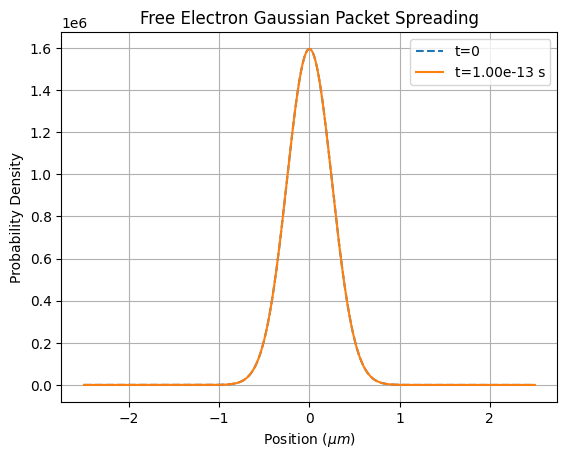

In [4]:
# --- Task 4: Free Particle Evolution ---
from scipy.fft import fft, ifft, fftfreq, fftshift

def free_particle_evolution():
    # Spatial Grid (Make domain large enough so wave doesn't hit edges)
    L = 5.0 # micrometers (large domain)
    N = 2048 # Number of points (power of 2 is faster for FFT)
    x = np.linspace(-L/2, L/2, N) * 1e-6 # Convert to meters
    dx = x[1] - x[0]

    # Initial Wavefunction: exp(-4 * (x_microns)^2)
    # Note: user prompt says exp(-4 * x^2).
    # If x is in standard SI (meters), x^2 is tiny.
    # Usually in these problems x is in convenient units or we need a huge coefficient.
    # Assuming the prompt implies x is dimensionless or scaled.
    # Let's assume x is in microns for the shape function to be visible.
    x_um = x * 1e6
    psi_0 = np.exp(-4 * x_um**2)

    # Normalise
    norm = np.sqrt(np.trapz(np.abs(psi_0)**2, x))
    psi_0 = psi_0 / norm
    print(f"\n--- Free Particle ---")
    print(f"Analytical Norm Constant: {(8/np.pi)**0.25:.4f}") # If x was dimensionless
    print(f"Numerical Norm Check: {np.trapz(np.abs(psi_0)**2, x):.4f}")

    # Momentum Grid (k-space)
    # k = 2*pi * freq
    k = 2 * np.pi * fftfreq(N, d=dx)

    # Time Evolution
    t_final = 1e-13 # seconds (very fast for electrons)
    t_steps = 50
    dt = t_final / t_steps

    # Plotting setup
    plt.figure()

    # FFT to k-space
    psi_k = fft(psi_0)

    # Evolution Loop
    # Energy E = (hbar*k)^2 / 2m
    # Phase factor = exp(-i E t / hbar) = exp(-i hbar k^2 t / 2m)

    # Let's plot initial and final
    psi_x_t = psi_0

    # Apply time evolution for full duration t_final
    evolution_operator = np.exp(-1j * (hbar * k**2 / (2 * m_e)) * t_final)
    psi_k_t = psi_k * evolution_operator
    psi_x_final = ifft(psi_k_t)

    # Plot
    plt.plot(x_um, np.abs(psi_0)**2, label='t=0', linestyle='--')
    plt.plot(x_um, np.abs(psi_x_final)**2, label=f't={t_final:.2e} s')
    plt.title("Free Electron Gaussian Packet Spreading")
    plt.xlabel("Position ($\mu m$)")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.grid(True)
    plt.show()

free_particle_evolution()